In [43]:
import tensorflow as tf
from tensorflow import keras
import os
import pandas as pd
from tensorflow.keras.applications import ResNet50V2
from sklearn.model_selection import StratifiedKFold
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

In [44]:
PATH = 'datasets/ISIC_2020_corrected'
os.listdir(PATH)

['multiclass',
 'subset.csv',
 'test_split.csv',
 'train',
 'train.csv',
 'train_resized',
 'train_sd_split.csv',
 'train_split.csv',
 'val_split.csv']

In [45]:
train = pd.read_csv(f'{PATH}/train_split.csv')
val = pd.read_csv(f'{PATH}/val_split.csv')
test = pd.read_csv(f'{PATH}/test_split.csv')
train.shape, val.shape

((23188, 9), (4969, 9))

In [46]:
train.head()

,image_name,patient_id,lesion_id,sex,age_approx,anatom_site_general_challenge,diagnosis,benign_malignant,target
0,ISIC_6828587,IP_7403252,IL_9414338,male,45.0,lower extremity,nevus,benign,0
1,ISIC_6555618,IP_6538458,IL_7328536,female,50.0,head/neck,unknown,benign,0
2,ISIC_4407024,IP_4050705,IL_3085841,female,40.0,lower extremity,unknown,benign,0
3,ISIC_5329118,IP_4277352,IL_6163665,female,40.0,torso,nevus,benign,0
4,ISIC_0779135,IP_4938349,IL_4355710,male,70.0,head/neck,unknown,benign,0


In [47]:
BATCH_SIZE = 64
AUTO = tf.data.experimental.AUTOTUNE

def decode(name, label):
    img = tf.io.read_file(name)
    img = tf.image.decode_jpeg(img, channels = 3)
    img = tf.cast(img, tf.float32)
    return img, label

def augment(img, label):
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_flip_up_down(img)
    img = tf.image.random_brightness(img, 30.0)
    img = tf.image.random_contrast(img, 0.8, 1.2)
    return img, label
    
def load_ds_augment(df):
    options = tf.data.Options()
    options.experimental_deterministic = False
    imgs, labels = df["image_name"].values, df["target"].values
    imgs = [f'{PATH}/train_resized/{name}.jpg' for name in imgs]
    ds = tf.data.Dataset.from_tensor_slices((imgs, labels))
    ds = ds.with_options(options)
    ds = ds.map(decode, num_parallel_calls=AUTO)
    ds = ds.map(augment, num_parallel_calls=AUTO)
    ds = ds.cache()
    ds = ds.shuffle(2048)
    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(buffer_size=AUTO)
    return ds

def load_ds(df):
    options = tf.data.Options()
    options.experimental_deterministic = False
    imgs, labels = df["image_name"].values, df["target"].values
    imgs = [f'{PATH}/train_resized/{name}.jpg' for name in imgs]
    ds = tf.data.Dataset.from_tensor_slices((imgs, labels))
    ds = ds.with_options(options)
    ds = ds.map(decode, num_parallel_calls=AUTO)
    ds = ds.cache()
    ds = ds.shuffle(2048)
    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(buffer_size=AUTO)
    return ds

In [48]:
train_ds = load_ds_augment(train)
val_ds = load_ds_augment(val)
test_ds = load_ds(test)

In [49]:
len(train_ds)*64

23232

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping i

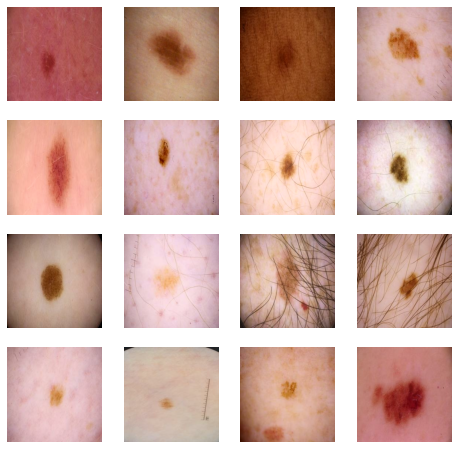

In [24]:
import random

r,c = 4, 4

fig = plt.figure(figsize=(2*c, 2*r))
for _r in range(r):
    for _c in range(c):
        plt.subplot(r, c, _r*c + _c + 1)
        for imgs, labels in train_ds.take(1):
            img = imgs[0].numpy() / 255
            plt.imshow(img)
            plt.axis(False)
plt.show()

In [66]:
IMAGE_SIZE = (256, 256, 3)

encoder = ResNet50V2(
    include_top=False,
    input_shape=IMAGE_SIZE,
    weights='imagenet'
)
encoder.trainable = False

inputs = keras.Input(shape=IMAGE_SIZE)
x = keras.layers.Rescaling(1./255)(inputs)
x = encoder(x, training=False)
x = keras.layers.GlobalAveragePooling2D()(x)
outputs = keras.layers.Dense(1, activation="sigmoid")(x)
model = keras.Model(inputs, outputs)
model.summary()

Model: "model_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_12 (InputLayer)       [(None, 256, 256, 3)]     0         
                                                                 
 rescaling_5 (Rescaling)     (None, 256, 256, 3)       0         
                                                                 
 resnet50v2 (Functional)     (None, 8, 8, 2048)        23564800  
                                                                 
 global_average_pooling2d_5   (None, 2048)             0         
 (GlobalAveragePooling2D)                                        
                                                                 
 dense_5 (Dense)             (None, 1)                 2049      
                                                                 
Total params: 23,566,849
Trainable params: 2,049
Non-trainable params: 23,564,800
___________________________________________

In [67]:
model.compile(
    optimizer=keras.optimizers.Adam(),
    loss=keras.losses.BinaryCrossentropy(),
    metrics=[keras.metrics.AUC(name="auc-ROC", curve='ROC'), keras.metrics.AUC(name="auc-PR", curve='PR')]
)

In [68]:
filepath = 'models/checkpoints/baseline2'
cb = tf.keras.callbacks.ModelCheckpoint(
    filepath = filepath,
    monitor="val_auc-PR",
    verbose=0,
    save_best_only=True,
    save_weights_only=True,
    mode="max"
)

In [69]:
history = model.fit(train_ds,
                    epochs=10,
                    validation_data=val_ds,
                    #validation_steps=10,
                    callbacks=[cb]
                   )

Epoch 1/10
363/363 [==============================] - 76s 201ms/step - loss: 0.0879 - auc-ROC: 0.6855 - auc-PR: 0.0413 - val_loss: 0.0724 - val_auc-ROC: 0.8201 - val_auc-PR: 0.1850
Epoch 2/10
363/363 [==============================] - 69s 190ms/step - loss: 0.0749 - auc-ROC: 0.8165 - auc-PR: 0.1119 - val_loss: 0.0714 - val_auc-ROC: 0.8357 - val_auc-PR: 0.1928
Epoch 3/10
363/363 [==============================] - 67s 186ms/step - loss: 0.0709 - auc-ROC: 0.8418 - auc-PR: 0.1677 - val_loss: 0.0707 - val_auc-ROC: 0.8474 - val_auc-PR: 0.2013
Epoch 4/10
363/363 [==============================] - 62s 172ms/step - loss: 0.0678 - auc-ROC: 0.8656 - auc-PR: 0.2097 - val_loss: 0.0712 - val_auc-ROC: 0.8322 - val_auc-PR: 0.1921
Epoch 5/10
363/363 [==============================] - 70s 193ms/step - loss: 0.0657 - auc-ROC: 0.8734 - auc-PR: 0.2408 - val_loss: 0.0711 - val_auc-ROC: 0.8428 - val_auc-PR: 0.1948
Epoch 6/10
363/363 [==============================] - 69s 191ms/step - loss: 0.0642 - auc-ROC: 

In [1]:
aucROC = history.history['auc-ROC']
val_aucROC = history.history['val_auc-ROC']

aucPR = history.history['auc-PR']
val_aucPR =history.history['val_auc-PR']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(1,11)
mpl.style.use('seaborn')
plt.figure(figsize=(16, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, aucROC, label='Valor AUC ROC de entrenamiento', marker='o')
plt.plot(epochs_range, val_aucROC, label='Valor AUC ROC de evaluación',marker='o')
plt.legend(loc='lower right')
plt.ylabel('AUC-ROC')
plt.xlabel('Épocas')
plt.xticks(epochs_range)
plt.title('Entrenamiento y evaluación AUC-ROC')

plt.figure(figsize=(16, 8))
plt.subplot(1, 2, 2)
plt.plot(epochs_range, aucPR, label='Valor AUC PR de entrenamiento',marker='o')
plt.plot(epochs_range, val_aucPR, label='Valor AUC PR de evaluación',marker='o')
plt.legend(loc='lower right')
plt.ylabel('AUC-PR')
plt.xlabel('Épocas')
plt.xticks(epochs_range)
plt.title('Entrenamiento y evaluación AUC-PR')

plt.figure(figsize=(16, 8))
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Valor función de pérdida de entrenamiento',marker='o')
plt.plot(epochs_range, val_loss, label='Valor función de pérdida de evaluación',marker='o')
plt.legend(loc='upper right')
plt.title('Entrenamiento y evaluación función de pérdida.')
plt.ylabel('Valor de función de pérdida')
plt.xlabel('Épocas')
plt.xticks(epochs_range)
plt.show()

NameError: name 'history' is not defined

In [72]:
model.load_weights(filepath)
results = model.evaluate(test_ds)
print(results)

78/78 [==============================] - 14s 173ms/step - loss: 0.0742 - auc-ROC: 0.8418 - auc-PR: 0.1013
[0.07421067357063293, 0.8417586088180542, 0.1012786328792572]


In [73]:
model.save('models/baseline2DataAugmentationROCPR.h5')